In [10]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "dualtest_experiments" else Path.cwd()
sys.path.append(str(DUALTEST_DIR))
DUALTEST_DIR = PROJECT_ROOT / "DUALTEST"
RESULTS_DIR = PROJECT_ROOT / "results"



print("PROJECT_ROOT:", PROJECT_ROOT)
print("DUALTEST_DIR:", DUALTEST_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

# El notebook buscará los CSV dentro de PROJECT_ROOT/results
DATA_DIR = RESULTS_DIR

PROJECT_ROOT: c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final
DUALTEST_DIR: c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\DUALTEST
RESULTS_DIR: c:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\results



# Análisis comparativo de resultados DUALTEST

Este notebook:

- carga los seis archivos de resultados;
- normaliza sus columnas;
- calcula **MAE** entre la etiqueta real y la probabilidad de membresía;
- compara ROC-AUC, PR-AUC, Brier score, log-loss, accuracy, precision, recall, F1, especificidad y FPR;
- compara también las señales individuales de DUALTEST;
- utiliza el `membership_threshold` guardado por el pipeline cuando está disponible;
- genera probabilidades y umbrales calibrados para los archivos de WikiMIA que no incluyen esas columnas;
- produce tablas y gráficos comparativos por archivo, modelo y dataset.

## Importante

El **MAE, Brier score, log-loss, ROC-AUC y PR-AUC no dependen de un umbral**.

Por lo tanto, el umbral principal ya no es 0.5. Se usa el `membership_threshold`
calibrado por el pipeline o, cuando no existe, uno calculado a partir del FPR objetivo.


In [11]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_absolute_error,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")



## 1. Configuración

Modificá `DATA_DIR` para que apunte a la carpeta donde se encuentran los CSV.

El cargador busca cada archivo tanto con el nombre indicado como agregando automáticamente la extensión `.csv`.


In [29]:
FILE_SPECS = {
    "wikimia_llama33_70b": "wikimia_llama33_70b_pythia410m_n1000_checkpoint",
    "wikimia_llama31_8b": "wikimia_llama31_8b_pythia410m_n1000_checkpoint",
    "booktection_sage_llama33_70b": "booktection_sage_medium_llama_3_3_70b_versatile",
    "booktection_sage_llama31_8b": "booktection_sage_medium_llama_3_1_8b_instant",
    "booktection_comparison_llama33_70b": "comparison_booktection_medium_llama_3_3_70b_versatile",
    "booktection_comparison_llama31_8b": "comparison_booktection_medium_llama_3_1_8b_instant",
}

RANDOM_STATE = 7
N_SPLITS = 5
TARGET_FPR = 0.01


In [30]:

def resolve_csv_path(data_dir: Path, stem: str) -> Path:
    candidates = [
        data_dir / stem,
        data_dir / f"{stem}.csv",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"No encontré '{stem}' ni '{stem}.csv' dentro de {data_dir.resolve()}"
    )


def infer_dataset_group(alias: str) -> str:
    if alias.startswith("wikimia"):
        return "WikiMIA"
    if "sage" in alias:
        return "BookTection + SAGE"
    return "BookTection comparison"


def infer_model_size(alias: str) -> str:
    return "Llama 3.3 70B" if "70b" in alias else "Llama 3.1 8B"


def normalize_bool(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    mapping = {
        "true": True, "false": False,
        "1": True, "0": False,
        "yes": True, "no": False,
    }
    return series.astype(str).str.strip().str.lower().map(mapping)


def load_result_file(alias: str, stem: str) -> pd.DataFrame:
    path = resolve_csv_path(DATA_DIR, stem)
    df = pd.read_csv(path)

    if "label" not in df.columns:
        raise ValueError(f"{path.name} no contiene la columna 'label'.")

    df = df.copy()
    df["source_file"] = path.name
    df["experiment"] = alias
    df["dataset_group"] = infer_dataset_group(alias)
    df["model_group"] = infer_model_size(alias)

    df["label"] = pd.to_numeric(df["label"], errors="coerce")

    numeric_cols = [
        "run_length",
        "edit_similarity",
        "p_rlb",
        "p_esb",
        "log_p_esb",
        "membership_probability",
        "membership_threshold",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "suspicious" in df.columns:
        df["suspicious"] = normalize_bool(df["suspicious"])

    return df


frames = []
for alias, stem in FILE_SPECS.items():
    try:
        frames.append(load_result_file(alias, stem))
        print(f"OK: {alias}")
    except FileNotFoundError as exc:
        print(f"FALTA: {alias} -> {exc}")

if not frames:
    raise RuntimeError("No se cargó ningún archivo. Revisá DATA_DIR y los nombres.")

df_all = pd.concat(frames, ignore_index=True, sort=False)
print("\nFilas cargadas:", len(df_all))
display(
    df_all.groupby(["dataset_group", "model_group", "experiment"])
          .size()
          .rename("n")
          .reset_index()
)


OK: wikimia_llama33_70b
OK: wikimia_llama31_8b
OK: booktection_sage_llama33_70b
OK: booktection_sage_llama31_8b
OK: booktection_comparison_llama33_70b
OK: booktection_comparison_llama31_8b

Filas cargadas: 964


,dataset_group,model_group,experiment,n
0,BookTection + SAGE,Llama 3.1 8B,booktection_sage_llama31_8b,200
1,BookTection + SAGE,Llama 3.3 70B,booktection_sage_llama33_70b,200
2,BookTection comparison,Llama 3.1 8B,booktection_comparison_llama31_8b,200
3,BookTection comparison,Llama 3.3 70B,booktection_comparison_llama33_70b,200
4,WikiMIA,Llama 3.1 8B,wikimia_llama31_8b,82
5,WikiMIA,Llama 3.3 70B,wikimia_llama33_70b,82



## 2. Construcción de features

Se utilizan las mismas señales del calibrador implementado en el proyecto:

\[
e_{\text{ESB}}=-s\log p_{\text{ESB}}.
\]

También se agregan versiones estables de las probabilidades:

- `neg_log_p_esb = -log_p_esb`;
- `neg_log10_p_esb = -log10(p_esb)`;
- `neg_log10_p_rlb = -log10(p_rlb)`.

En todos estos scores, un valor más alto se interpreta como mayor evidencia de memorización.


In [31]:

EPS = 1e-300

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "log_p_esb" in out.columns:
        out["neg_log_p_esb"] = -out["log_p_esb"]
    elif "p_esb" in out.columns:
        out["neg_log_p_esb"] = -np.log(out["p_esb"].clip(lower=EPS))
    else:
        out["neg_log_p_esb"] = np.nan

    if "p_esb" in out.columns:
        out["neg_log10_p_esb"] = -np.log10(out["p_esb"].clip(lower=EPS))
    else:
        out["neg_log10_p_esb"] = out["neg_log_p_esb"] / np.log(10)

    if "p_rlb" in out.columns:
        out["neg_log10_p_rlb"] = -np.log10(out["p_rlb"].clip(lower=EPS))
    else:
        out["neg_log10_p_rlb"] = np.nan

    out["esb_evidence"] = out["edit_similarity"] * out["neg_log_p_esb"]

    return out


df_all = add_features(df_all)

FEATURES = [
    "run_length",
    "edit_similarity",
    "esb_evidence",
]

display(df_all[FEATURES + ["label"]].describe().T)


,count,mean,std,min,25%,50%,75%,max
run_length,964.0000,0.8589,2.5199,0.0000,0.0000,0.0000,1.0000,62.0000
edit_similarity,964.0000,0.2692,0.0413,0.0242,0.2475,0.2669,0.2865,0.8701
esb_evidence,964.0000,42.2710,8.2678,5.2820,37.5971,41.9715,46.1128,167.2791
label,964.0000,0.5207,0.4998,0.0000,0.0000,1.0000,1.0000,1.0000



## 3. Probabilidades y umbrales de comparación

Los archivos de BookTection ya incluyen:

- `membership_probability`;
- `membership_threshold`;
- `suspicious`.

En esos casos se conservan los valores calculados por el pipeline.

Los archivos de WikiMIA no incluyen esas columnas. Para poder evaluarlos de la misma
forma, se generan probabilidades **out-of-fold (OOF)** mediante regresión logística
calibrada y luego se calcula un umbral por experimento usando las probabilidades de
los no miembros:

\[
\tau = Q_{1-\alpha}\left(\hat p \mid y=0\right),
\]

donde \(\alpha\) es el FPR objetivo.

Finalmente se crean tres columnas unificadas:

- `probability_for_comparison`;
- `threshold_for_comparison`;
- `suspicious_for_comparison`.

Para BookTection toman los valores originales del CSV. Para WikiMIA toman los valores
OOF y el umbral calibrado en este notebook.


In [32]:

def make_calibrated_model():
    base = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            max_iter=2000,
            class_weight=None,
            random_state=RANDOM_STATE,
        )),
    ])

    return CalibratedClassifierCV(
        estimator=base,
        method="isotonic",
        cv=3,
    )


def add_oof_probabilities_and_thresholds(
    df: pd.DataFrame,
    group_col: str = "experiment",
    features: list[str] = FEATURES,
    n_splits: int = N_SPLITS,
    target_fpr: float = TARGET_FPR,
) -> pd.DataFrame:
    out = df.copy()

    # Guardamos los valores originales cuando existen.
    out["membership_probability_original"] = (
        out["membership_probability"]
        if "membership_probability" in out.columns
        else np.nan
    )
    out["membership_threshold_original"] = (
        out["membership_threshold"]
        if "membership_threshold" in out.columns
        else np.nan
    )
    out["suspicious_original"] = (
        out["suspicious"]
        if "suspicious" in out.columns
        else np.nan
    )

    out["membership_probability_oof"] = np.nan
    out["membership_threshold_oof"] = np.nan
    out["suspicious_oof"] = np.nan

    for group_name, idx in out.groupby(group_col).groups.items():
        subset = out.loc[idx].copy()
        valid = subset.dropna(subset=features + ["label"]).copy()

        if valid["label"].nunique() < 2:
            print(f"Se omite {group_name}: sólo tiene una clase.")
            continue

        min_class = int(valid["label"].value_counts().min())
        splits = min(n_splits, min_class)

        if splits < 2:
            print(f"Se omite {group_name}: no hay suficientes muestras por clase.")
            continue

        cv = StratifiedKFold(
            n_splits=splits,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

        X = valid[features]
        y = valid["label"].astype(int)
        oof = np.full(len(valid), np.nan)

        for train_pos, test_pos in cv.split(X, y):
            model = make_calibrated_model()
            model.fit(X.iloc[train_pos], y.iloc[train_pos])
            oof[test_pos] = model.predict_proba(X.iloc[test_pos])[:, 1]

        out.loc[valid.index, "membership_probability_oof"] = oof

        nonmember_probs = pd.Series(oof, index=valid.index)[y.values == 0]
        threshold = float(nonmember_probs.quantile(1 - target_fpr))

        out.loc[valid.index, "membership_threshold_oof"] = threshold
        out.loc[valid.index, "suspicious_oof"] = oof >= threshold

    # Comparación principal:
    # - usa valores originales si el CSV ya los trae;
    # - usa valores OOF para WikiMIA.
    has_original_prob = out["membership_probability_original"].notna()
    has_original_thr = out["membership_threshold_original"].notna()

    out["probability_for_comparison"] = np.where(
        has_original_prob,
        out["membership_probability_original"],
        out["membership_probability_oof"],
    )

    out["threshold_for_comparison"] = np.where(
        has_original_thr,
        out["membership_threshold_original"],
        out["membership_threshold_oof"],
    )

    # Si suspicious original existe, se respeta.
    # Si no existe, se reconstruye usando probabilidad y threshold.
    out["suspicious_for_comparison"] = np.where(
        out["suspicious_original"].notna(),
        out["suspicious_original"],
        out["probability_for_comparison"] >= out["threshold_for_comparison"],
    )

    out["suspicious_for_comparison"] = (
        pd.Series(out["suspicious_for_comparison"], index=out.index)
        .astype("boolean")
    )

    return out


df_all = add_oof_probabilities_and_thresholds(df_all)

display(
    df_all.groupby("experiment")[
        [
            "membership_probability_original",
            "membership_probability_oof",
            "membership_threshold_original",
            "membership_threshold_oof",
        ]
    ].count()
)


,membership_probability_original,membership_probability_oof,membership_threshold_original,membership_threshold_oof
experiment,,,,
booktection_comparison_llama31_8b,200,200,200,200
booktection_comparison_llama33_70b,200,200,200,200
booktection_sage_llama31_8b,200,200,200,200
booktection_sage_llama33_70b,200,200,200,200
wikimia_llama31_8b,0,82,0,82
wikimia_llama33_70b,0,82,0,82



## 4. Funciones de evaluación

Las métricas probabilísticas se calculan directamente sobre
`probability_for_comparison`.

Las métricas binarias se calculan a partir de `suspicious_for_comparison`, que respeta
el `membership_threshold` guardado en cada archivo. Para WikiMIA utiliza el umbral
calibrado en la sección anterior.


In [33]:

def classification_metrics_from_predictions(
    y_true,
    y_prob,
    y_pred,
    threshold_values=None,
):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = np.asarray(y_pred, dtype=int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan

    threshold_values = (
        np.asarray(threshold_values, dtype=float)
        if threshold_values is not None
        else np.array([np.nan])
    )

    return {
        "n": len(y_true),
        "positive_rate": y_true.mean(),
        "mae": mean_absolute_error(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "log_loss": log_loss(y_true, np.clip(y_prob, 1e-15, 1 - 1e-15)),
        "roc_auc": roc_auc_score(y_true, y_prob)
            if len(np.unique(y_true)) == 2 else np.nan,
        "pr_auc": average_precision_score(y_true, y_prob)
            if len(np.unique(y_true)) == 2 else np.nan,
        "threshold_min": np.nanmin(threshold_values),
        "threshold_max": np.nanmax(threshold_values),
        "threshold_mean": np.nanmean(threshold_values),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "fpr": fpr,
        "fnr": fnr,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }


def evaluate_groups(
    df,
    probability_col="probability_for_comparison",
    prediction_col="suspicious_for_comparison",
    threshold_col="threshold_for_comparison",
    group_cols=("experiment", "dataset_group", "model_group"),
):
    rows = []

    for keys, group in df.groupby(list(group_cols), dropna=False):
        clean = group.dropna(
            subset=["label", probability_col, prediction_col, threshold_col]
        ).copy()
        clean = clean[clean["label"].isin([0, 1])]

        if clean.empty or clean["label"].nunique() < 2:
            continue

        y_true = clean["label"].astype(int)
        y_prob = clean[probability_col].astype(float)
        y_pred = clean[prediction_col].astype(bool).astype(int)
        thresholds = clean[threshold_col].astype(float)

        row = dict(zip(
            group_cols,
            keys if isinstance(keys, tuple) else (keys,),
        ))
        row.update(
            classification_metrics_from_predictions(
                y_true,
                y_prob,
                y_pred,
                threshold_values=thresholds,
            )
        )
        rows.append(row)

    return pd.DataFrame(rows)


## 5. Comparación principal usando `membership_threshold`

In [34]:

metrics_main = evaluate_groups(df_all)

main_cols = [
    "experiment",
    "dataset_group",
    "model_group",
    "n",
    "mae",
    "brier",
    "log_loss",
    "roc_auc",
    "pr_auc",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "specificity",
    "fpr",
    "threshold_min",
    "threshold_max",
    "threshold_mean",
]

display(
    metrics_main[main_cols]
    .sort_values(["dataset_group", "model_group"])
)


,experiment,dataset_group,model_group,n,mae,brier,log_loss,roc_auc,pr_auc,accuracy,precision,recall,f1,specificity,fpr,threshold_min,threshold_max,threshold_mean
2,booktection_sage_llama31_8b,BookTection + SAGE,Llama 3.1 8B,200,0.4983,0.2519,0.6978,0.5770,0.5489,0.4950,0.0000,0.0000,0.0000,0.9900,0.0100,0.7501,0.7501,0.7501
3,booktection_sage_llama33_70b,BookTection + SAGE,Llama 3.3 70B,200,0.4760,0.2373,0.6677,0.6277,0.6342,0.5350,0.8889,0.0800,0.1468,0.9900,0.0100,0.7501,0.7501,0.7501
0,booktection_comparison_llama31_8b,BookTection comparison,Llama 3.1 8B,200,0.4778,0.2337,0.6582,0.6680,0.6782,0.5250,1.0000,0.0500,0.0952,1.0000,0.0000,0.7501,0.7501,0.7501
1,booktection_comparison_llama33_70b,BookTection comparison,Llama 3.3 70B,200,0.4750,0.2360,0.6640,0.6639,0.6602,0.5300,0.7500,0.0900,0.1607,0.9700,0.0300,0.7501,0.7501,0.7501
4,wikimia_llama31_8b,WikiMIA,Llama 3.1 8B,82,0.4682,0.2468,0.6892,0.5405,0.6661,0.3902,0.6667,0.0392,0.0741,0.9677,0.0323,0.8018,0.8018,0.8018
5,wikimia_llama33_70b,WikiMIA,Llama 3.3 70B,82,0.4624,0.2508,0.7211,0.5598,0.6452,0.3659,0.0000,0.0000,0.0000,0.9677,0.0323,0.9319,0.9319,0.9319



## 6. MAE principal

Esta tabla ordena los experimentos de menor a mayor MAE. Para interpretar conjuntamente la calidad de las probabilidades conviene mirar también Brier score, log-loss y ROC-AUC.


In [35]:

mae_table = (
    metrics_main[
        ["experiment", "dataset_group", "model_group", "n", "mae", "brier", "log_loss", "roc_auc", "pr_auc"]
    ]
    .sort_values("mae")
    .reset_index(drop=True)
)

display(mae_table)


,experiment,dataset_group,model_group,n,mae,brier,log_loss,roc_auc,pr_auc
0,wikimia_llama33_70b,WikiMIA,Llama 3.3 70B,82,0.4624,0.2508,0.7211,0.5598,0.6452
1,wikimia_llama31_8b,WikiMIA,Llama 3.1 8B,82,0.4682,0.2468,0.6892,0.5405,0.6661
2,booktection_comparison_llama33_70b,BookTection comparison,Llama 3.3 70B,200,0.4750,0.2360,0.6640,0.6639,0.6602
3,booktection_sage_llama33_70b,BookTection + SAGE,Llama 3.3 70B,200,0.4760,0.2373,0.6677,0.6277,0.6342
4,booktection_comparison_llama31_8b,BookTection comparison,Llama 3.1 8B,200,0.4778,0.2337,0.6582,0.6680,0.6782
5,booktection_sage_llama31_8b,BookTection + SAGE,Llama 3.1 8B,200,0.4983,0.2519,0.6978,0.5770,0.5489


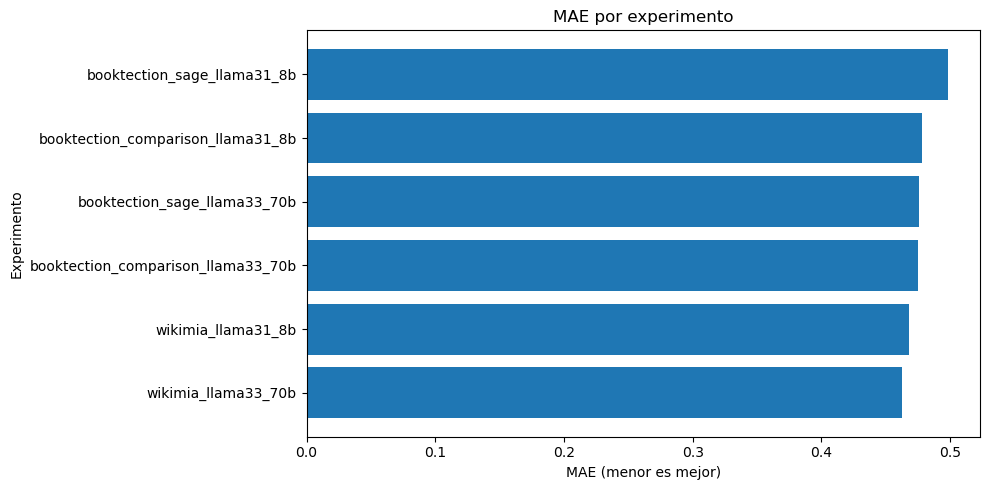

In [36]:

plot_df = mae_table.sort_values("mae", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["experiment"], plot_df["mae"])
plt.xlabel("MAE (menor es mejor)")
plt.ylabel("Experimento")
plt.title("MAE por experimento")
plt.tight_layout()
plt.show()


## 7. Comparación directa 70B vs 8B por dataset

In [37]:

comparison_table = (
    metrics_main.pivot_table(
        index="dataset_group",
        columns="model_group",
        values=["mae", "brier", "roc_auc", "pr_auc", "f1", "recall", "precision"],
    )
)

display(comparison_table)


brier                         f1                \
model_group            Llama 3.1 8B Llama 3.3 70B Llama 3.1 8B Llama 3.3 70B   
dataset_group                                                                  
BookTection + SAGE           0.2519        0.2373       0.0000        0.1468   
BookTection comparison       0.2337        0.2360       0.0952        0.1607   
WikiMIA                      0.2468        0.2508       0.0741        0.0000   

                                mae                     pr_auc                \
model_group            Llama 3.1 8B Llama 3.3 70B Llama 3.1 8B Llama 3.3 70B   
dataset_group                                                                  
BookTection + SAGE           0.4983        0.4760       0.5489        0.6342   
BookTection comparison       0.4778        0.4750       0.6782        0.6602   
WikiMIA                      0.4682        0.4624       0.6661        0.6452   

                          precision                     recall                \
model_group            Llama 3.1 8B Llama 3.3 70B Llama 3.1 8B Llama 3.3 70B   
dataset_group                                                                  
BookTection + SAGE           0.0000        0.8889       0.0000        0.0800   
BookTection comparison       1.0000        0.7500       0.0500        0.0900   
WikiMIA                      0.6667        0.0000       0.0392        0.0000   

                            roc_auc                
model_group            Llama 3.1 8B Llama 3.3 70B  
dataset_group                                      
BookTection + SAGE           0.5770        0.6277  
BookTection comparison       0.6680        0.6639  
WikiMIA                      0.5405        0.5598


## 8. Desempeño de cada señal individual

Esta sección calcula ROC-AUC y PR-AUC usando cada métrica como score continuo, sin convertirla todavía en probabilidad.

Orientación utilizada:

- `run_length`: mayor = más sospechoso;
- `edit_similarity`: mayor = más sospechoso;
- `neg_log10_p_rlb`: mayor = menor probabilidad bajo el modelo de referencia;
- `neg_log_p_esb`: mayor = menor probabilidad bajo el modelo de referencia;
- `esb_evidence`: mayor = similitud alta e improbabilidad alta.


In [38]:

RAW_SCORES = [
    "run_length",
    "edit_similarity",
    "neg_log10_p_rlb",
    "neg_log_p_esb",
    "esb_evidence",
]


def evaluate_raw_scores(df, group_col="experiment"):
    rows = []

    for experiment, group in df.groupby(group_col):
        for score in RAW_SCORES:
            clean = group.dropna(subset=["label", score]).copy()
            clean = clean[clean["label"].isin([0, 1])]

            if clean.empty or clean["label"].nunique() < 2:
                continue

            y = clean["label"].astype(int)
            values = clean[score].astype(float)

            rows.append({
                "experiment": experiment,
                "dataset_group": clean["dataset_group"].iloc[0],
                "model_group": clean["model_group"].iloc[0],
                "score": score,
                "n": len(clean),
                "roc_auc": roc_auc_score(y, values),
                "pr_auc": average_precision_score(y, values),
                "mean_member": values[y == 1].mean(),
                "mean_nonmember": values[y == 0].mean(),
                "median_member": values[y == 1].median(),
                "median_nonmember": values[y == 0].median(),
            })

    return pd.DataFrame(rows)


raw_score_metrics = evaluate_raw_scores(df_all)

display(
    raw_score_metrics.sort_values(
        ["experiment", "roc_auc"],
        ascending=[True, False],
    )
)


,experiment,dataset_group,model_group,score,n,roc_auc,pr_auc,mean_member,mean_nonmember,median_member,median_nonmember
4,booktection_comparison_llama31_8b,BookTection comparison,Llama 3.1 8B,esb_evidence,200,0.6621,0.6893,43.3075,39.6450,42.8323,39.4253
1,booktection_comparison_llama31_8b,BookTection comparison,Llama 3.1 8B,edit_similarity,200,0.6277,0.6191,0.2695,0.2573,0.2723,0.2557
3,booktection_comparison_llama31_8b,BookTection comparison,Llama 3.1 8B,neg_log_p_esb,200,0.5807,0.6026,160.6641,154.5425,159.2208,155.9459
2,booktection_comparison_llama31_8b,BookTection comparison,Llama 3.1 8B,neg_log10_p_rlb,200,0.5476,0.5732,1.9150,1.1881,-0.0000,-0.0000
0,booktection_comparison_llama31_8b,BookTection comparison,Llama 3.1 8B,run_length,200,0.5418,0.5469,0.6900,0.4000,0.0000,0.0000
6,booktection_comparison_llama33_70b,BookTection comparison,Llama 3.3 70B,edit_similarity,200,0.6593,0.6846,0.2801,0.2573,0.2737,0.2587
9,booktection_comparison_llama33_70b,BookTection comparison,Llama 3.3 70B,esb_evidence,200,0.6515,0.6453,46.6721,42.2340,45.5632,42.1498
7,booktection_comparison_llama33_70b,BookTection comparison,Llama 3.3 70B,neg_log10_p_rlb,200,0.5970,0.6415,6.1761,1.8259,-0.0000,-0.0000
5,booktection_comparison_llama33_70b,BookTection comparison,Llama 3.3 70B,run_length,200,0.5783,0.5977,1.8900,0.6500,0.0000,0.0000
8,booktection_comparison_llama33_70b,BookTection comparison,Llama 3.3 70B,neg_log_p_esb,200,0.5431,0.5546,166.5096,164.2525,165.7436,163.4941


In [39]:

auc_pivot = raw_score_metrics.pivot_table(
    index="experiment",
    columns="score",
    values="roc_auc",
)

display(auc_pivot)


score,edit_similarity,esb_evidence,neg_log10_p_rlb,neg_log_p_esb,run_length
experiment,,,,,
booktection_comparison_llama31_8b,0.6277,0.6621,0.5476,0.5807,0.5418
booktection_comparison_llama33_70b,0.6593,0.6515,0.5970,0.5431,0.5783
booktection_sage_llama31_8b,0.5825,0.5561,0.5447,0.5068,0.5459
booktection_sage_llama33_70b,0.6321,0.6311,0.4888,0.5352,0.4871
wikimia_llama31_8b,0.5560,0.4497,0.4124,0.4042,0.4165
wikimia_llama33_70b,0.5471,0.4168,0.4747,0.3972,0.4668


## 9. Curvas ROC

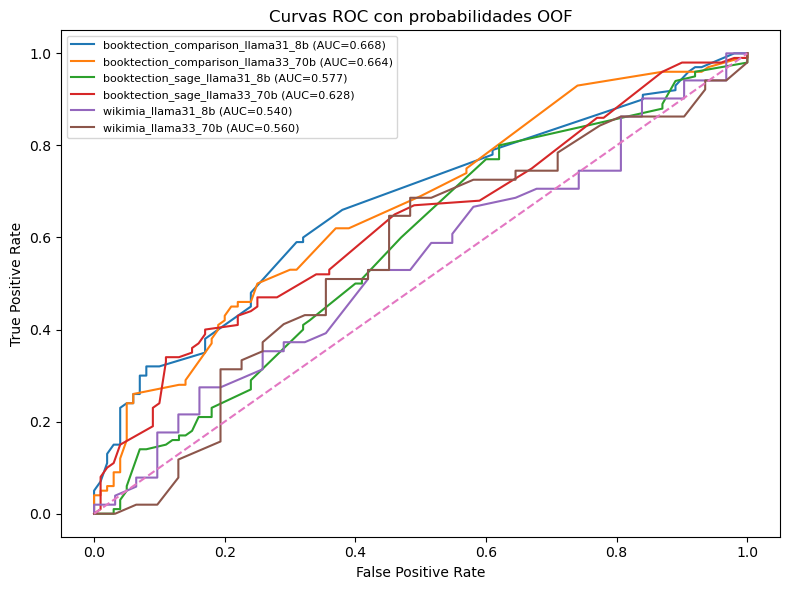

In [40]:

plt.figure(figsize=(8, 6))

for experiment, group in df_all.groupby("experiment"):
    clean = group.dropna(subset=["label", "probability_for_comparison"]).copy()
    clean = clean[clean["label"].isin([0, 1])]

    if clean["label"].nunique() < 2:
        continue

    y = clean["label"].astype(int)
    p = clean["probability_for_comparison"].astype(float)
    fpr, tpr, _ = roc_curve(y, p)
    auc = roc_auc_score(y, p)

    plt.plot(fpr, tpr, label=f"{experiment} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC con probabilidades OOF")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 10. Curvas Precision–Recall

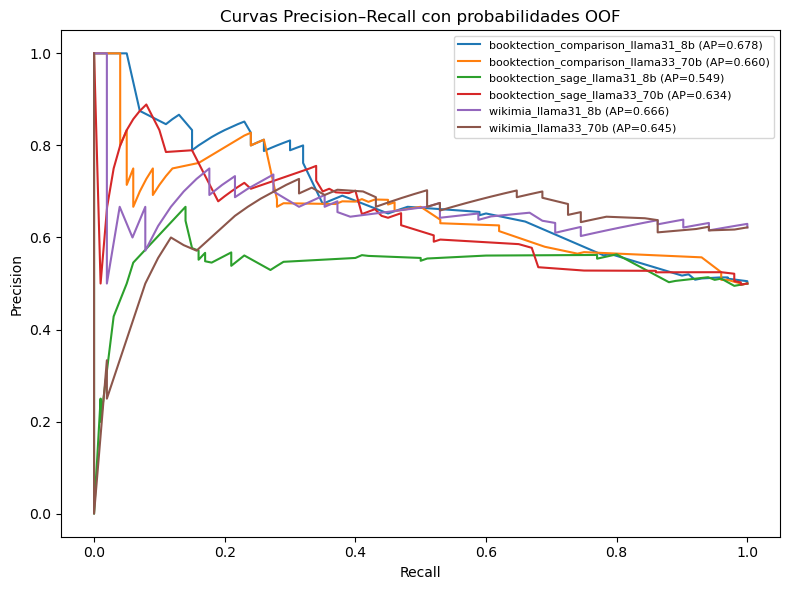

In [41]:

plt.figure(figsize=(8, 6))

for experiment, group in df_all.groupby("experiment"):
    clean = group.dropna(subset=["label", "probability_for_comparison"]).copy()
    clean = clean[clean["label"].isin([0, 1])]

    if clean["label"].nunique() < 2:
        continue

    y = clean["label"].astype(int)
    p = clean["probability_for_comparison"].astype(float)
    precision, recall, _ = precision_recall_curve(y, p)
    ap = average_precision_score(y, p)

    plt.plot(recall, precision, label=f"{experiment} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision–Recall con probabilidades OOF")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 11. Curvas de calibración

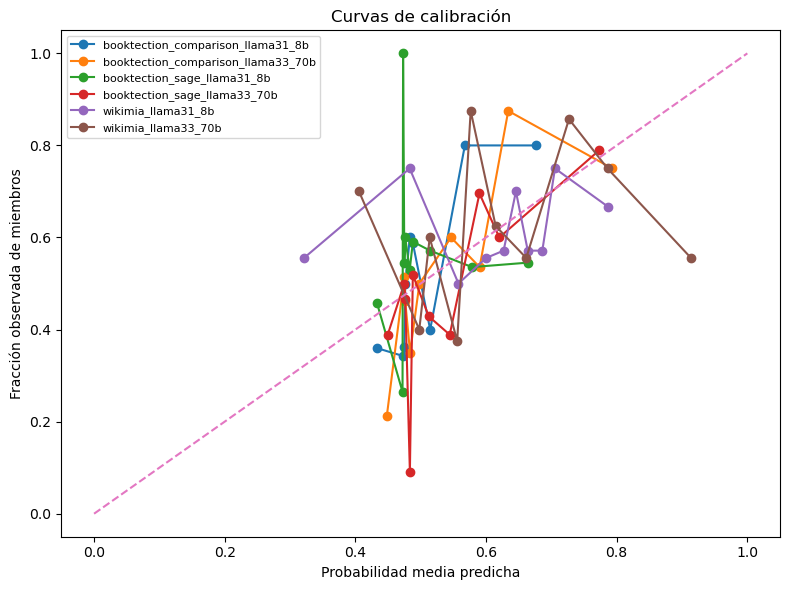

In [42]:

plt.figure(figsize=(8, 6))

for experiment, group in df_all.groupby("experiment"):
    clean = group.dropna(subset=["label", "probability_for_comparison"]).copy()
    clean = clean[clean["label"].isin([0, 1])]

    if clean["label"].nunique() < 2 or len(clean) < 20:
        continue

    y = clean["label"].astype(int)
    p = clean["probability_for_comparison"].astype(float)

    frac_pos, mean_pred = calibration_curve(
        y,
        p,
        n_bins=10,
        strategy="quantile",
    )
    plt.plot(mean_pred, frac_pos, marker="o", label=experiment)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Probabilidad media predicha")
plt.ylabel("Fracción observada de miembros")
plt.title("Curvas de calibración")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()



## 12. Verificación del umbral aplicado

Esta tabla verifica que la clasificación `suspicious_for_comparison` coincide con la
regla:

\[
	exttt{membership\_probability}
\ge
	exttt{membership\_threshold}.
\]


In [43]:

check = df_all.dropna(
    subset=[
        "probability_for_comparison",
        "threshold_for_comparison",
        "suspicious_for_comparison",
    ]
).copy()

check["reconstructed_suspicious"] = (
    check["probability_for_comparison"]
    >= check["threshold_for_comparison"]
)

check["matches_threshold_rule"] = (
    check["reconstructed_suspicious"]
    == check["suspicious_for_comparison"].astype(bool)
)

display(
    check.groupby("experiment")["matches_threshold_rule"]
    .agg(["count", "mean"])
    .rename(columns={"mean": "proportion_correcta"})
)


,count,proportion_correcta
experiment,,
booktection_comparison_llama31_8b,200,1.0000
booktection_comparison_llama33_70b,200,1.0000
booktection_sage_llama31_8b,200,1.0000
booktection_sage_llama33_70b,200,1.0000
wikimia_llama31_8b,82,1.0000
wikimia_llama33_70b,82,1.0000



## 13. Métricas por libro

Para BookTection puede ser útil identificar libros en los que el método funciona particularmente bien o mal.


In [44]:

def metrics_by_book(df):
    rows = []

    if "book_id" not in df.columns:
        return pd.DataFrame()

    for (experiment, book_id), group in df.groupby(["experiment", "book_id"]):
        clean = group.dropna(subset=["label", "probability_for_comparison"])

        if clean.empty or clean["label"].nunique() < 2:
            continue

        result = classification_metrics(
            clean["label"].astype(int),
            clean["probability_for_comparison"].astype(float),
            )
        result.update({
            "experiment": experiment,
            "book_id": book_id,
        })
        rows.append(result)

    return pd.DataFrame(rows)


book_metrics = metrics_by_book(df_all)

if book_metrics.empty:
    print("No hay libros con ambas clases suficientes para calcular métricas.")
else:
    display(
        book_metrics[
            ["experiment", "book_id", "n", "mae", "brier", "roc_auc", "pr_auc", "f1"]
        ].sort_values(["experiment", "mae"])
    )


No hay libros con ambas clases suficientes para calcular métricas.



## 14. Intervalos de confianza por bootstrap

Se calculan intervalos de confianza del 95 % para MAE, ROC-AUC y Brier score. Esto ayuda a distinguir diferencias reales de variaciones muestrales.


In [45]:

def bootstrap_ci(
    y_true,
    y_prob,
    metric_fn,
    n_boot=1000,
    confidence=0.95,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    values = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        y_b = y_true[idx]
        p_b = y_prob[idx]

        if metric_fn is roc_auc_score and len(np.unique(y_b)) < 2:
            continue

        values.append(metric_fn(y_b, p_b))

    alpha = 1 - confidence
    return (
        float(np.quantile(values, alpha / 2)),
        float(np.quantile(values, 1 - alpha / 2)),
    )


bootstrap_rows = []

for experiment, group in df_all.groupby("experiment"):
    clean = group.dropna(subset=["label", "probability_for_comparison"])
    clean = clean[clean["label"].isin([0, 1])]

    if clean["label"].nunique() < 2:
        continue

    y = clean["label"].astype(int).to_numpy()
    p = clean["probability_for_comparison"].astype(float).to_numpy()

    mae_lo, mae_hi = bootstrap_ci(y, p, mean_absolute_error)
    brier_lo, brier_hi = bootstrap_ci(y, p, brier_score_loss)
    auc_lo, auc_hi = bootstrap_ci(y, p, roc_auc_score)

    bootstrap_rows.append({
        "experiment": experiment,
        "mae": mean_absolute_error(y, p),
        "mae_ci_low": mae_lo,
        "mae_ci_high": mae_hi,
        "brier": brier_score_loss(y, p),
        "brier_ci_low": brier_lo,
        "brier_ci_high": brier_hi,
        "roc_auc": roc_auc_score(y, p),
        "roc_auc_ci_low": auc_lo,
        "roc_auc_ci_high": auc_hi,
    })

bootstrap_table = pd.DataFrame(bootstrap_rows)
display(bootstrap_table.sort_values("mae"))


,experiment,mae,mae_ci_low,mae_ci_high,brier,brier_ci_low,brier_ci_high,roc_auc,roc_auc_ci_low,roc_auc_ci_high
5,wikimia_llama33_70b,0.4624,0.4254,0.5005,0.2508,0.2141,0.2909,0.5598,0.4236,0.6884
4,wikimia_llama31_8b,0.4682,0.4330,0.5033,0.2468,0.2121,0.2825,0.5405,0.4111,0.6694
1,booktection_comparison_llama33_70b,0.4750,0.4610,0.4897,0.2360,0.2241,0.2495,0.6639,0.5844,0.7371
3,booktection_sage_llama33_70b,0.4760,0.4610,0.4902,0.2373,0.2245,0.2506,0.6277,0.5505,0.7047
0,booktection_comparison_llama31_8b,0.4778,0.4672,0.4875,0.2337,0.2254,0.2416,0.6680,0.5953,0.7408
2,booktection_sage_llama31_8b,0.4983,0.4895,0.5065,0.2519,0.2431,0.2607,0.5770,0.4970,0.6556



## 15. Exportación de resultados

Se guardan tablas listas para utilizar en el informe.


In [46]:

OUTPUT_DIR = DATA_DIR / "analysis_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_main.to_csv(
    OUTPUT_DIR / "metricas_con_membership_threshold.csv",
    index=False,
)
mae_table.to_csv(OUTPUT_DIR / "ranking_mae.csv", index=False)
raw_score_metrics.to_csv(
    OUTPUT_DIR / "metricas_scores_individuales.csv",
    index=False,
)
bootstrap_table.to_csv(
    OUTPUT_DIR / "intervalos_confianza_bootstrap.csv",
    index=False,
)

if not book_metrics.empty:
    book_metrics.to_csv(
        OUTPUT_DIR / "metricas_por_libro.csv",
        index=False,
    )

df_all[
    [
        "experiment",
        "label",
        "probability_for_comparison",
        "threshold_for_comparison",
        "suspicious_for_comparison",
    ]
].to_csv(
    OUTPUT_DIR / "predicciones_y_umbrales_utilizados.csv",
    index=False,
)

print("Resultados guardados en:", OUTPUT_DIR.resolve())


Resultados guardados en: C:\Users\isiva\OneDrive\Escritorio\Ingenieria de software\NLP_Proyecto_Final\results\analysis_outputs



## 16. Guía de interpretación

Para comparar modelos y datasets:

- **MAE, Brier y log-loss:** cuanto más bajos, mejor calibradas y más cercanas a la
  etiqueta están las probabilidades.
- **ROC-AUC:** mide la capacidad de ordenar miembros por encima de no miembros.
- **PR-AUC:** es especialmente útil cuando las clases están desbalanceadas.
- **Precision:** de las muestras marcadas como miembros, cuántas realmente lo eran.
- **Recall:** de todos los miembros reales, cuántos fueron detectados.
- **FPR:** proporción de no miembros incorrectamente marcados como miembros.
- **Especificidad:** proporción de no miembros correctamente descartados.
- **F1:** equilibrio entre precision y recall.

Las métricas binarias de este notebook no utilizan un corte genérico de 0.5. Utilizan
el `membership_threshold` real de cada experimento. En los archivos de WikiMIA, donde
el umbral no estaba guardado, se calcula con el FPR objetivo indicado en `TARGET_FPR`.
